# Impacto económico del modelo propuesto

Traduce el modelo de Manolo (WOE + Regresión Logística, política **PD < 20%**) a soles.

- **No reentrena ni modifica nada**: carga `model/modelo_logistico_woe.pkl` con `src/predict.py`.
- **Misma regla metodológica**: TRAIN aprende → VALIDATION decide → OOT confirma. Todo umbral se fija en VALIDATION y se aplica sin cambios en OOT.
- **P&L con el TARGET observado**; la PD solo se usa para ordenar y decidir.

Escenarios (misma población, mismo desempeño observado):

| | Escenario | Qué representa |
|---|---|---|
| A | Situación actual | Aprobar a todos (la base solo contiene clientes renovados) |
| B | Modelo del banco | `PREDICCION_MODELO_ANTERIOR`, aprobando el **mismo número** de clientes que la política propuesta |
| C | Modelo propuesto | PD < 20% |

**Ahorro total (C − A) = valor de tener una política (B − A) + valor del mejor modelo (C − B).**

Toda la lógica vive en `impacto_economico.py`; este notebook solo la ejecuta y muestra los resultados.

In [1]:
import pandas as pd
from IPython.display import Image, display

import impacto_economico as ie

r = ie.ejecutar(guardar=True)

SOLES = lambda x: f"S/ {x:,.0f}"
PCT = lambda x: f"{x:.2f}%"

def formato(df, soles=(), pct=()):
    return df.style.format({**{c: SOLES for c in soles}, **{c: PCT for c in pct}}, na_rep="—").hide(axis="index")

[INFO] converting into woe values ...


[INFO] converting into woe values ...


[INFO] converting into woe values ...


[INFO] converting into woe values ...


[INFO] converting into woe values ...


## 1. Reproducción del modelo

`ejecutar()` se detiene si AUC/KS no coinciden con lo publicado por Manolo (tolerancia 1e-6) o si la política OOT no da 73.47% de aprobación y 6.96% de bad rate. Se agrega el score del banco como benchmark.

In [2]:
r["metricas"].round(4)

,Muestra,N,Bad_Rate_%,AUC,Gini,KS,AUC_banco,Gini_banco,KS_banco,Score_banco_NaN
0,TRAIN,38462,16.0184,0.7995,0.5990,0.4454,0.7380,0.4759,0.3388,3
1,VALIDATION,10583,14.9485,0.7908,0.5816,0.4322,0.7102,0.4204,0.2978,2
2,OOT,10955,14.1305,0.7964,0.5927,0.4495,0.7223,0.4446,0.3244,0


### Comparación de modelos: actual del banco, Regresión Logística WOE y CatBoost

Gini, AUC y KS por periodo. El modelo actual del banco y la logística se calculan aquí. CatBoost no se guardó, así que se citan las métricas oficiales del notebook 03 (reentrenarlo en otro equipo da diferencias menores a 0.1 pts de Gini en VALIDATION y OOT). En el modelo del banco, "TRAIN" es solo el periodo: no fue entrenado con esta partición.

modelo,variables,Gini_TRAIN,Gini_VALIDATION,Gini_OOT,AUC_TRAIN,AUC_VALIDATION,AUC_OOT,KS_TRAIN,KS_VALIDATION,KS_OOT,caida_gini_train_oot_pts,fuente
Modelo actual del banco,n.d.,0.476,0.420,0.445,0.738,0.710,0.722,0.339,0.298,0.324,3.1,Calculado sobre la columna PREDICCION_MODELO_ANTERIOR
Regresión Logística WOE,18,0.599,0.582,0.593,0.800,0.791,0.796,0.445,0.432,0.450,0.6,Calculado con model/modelo_logistico_woe.pkl
CatBoost (benchmark),45,0.726,0.616,0.609,0.863,0.808,0.805,0.554,0.461,0.463,11.7,Reportado en notebooks/03_benchmark_catboost.ipynb


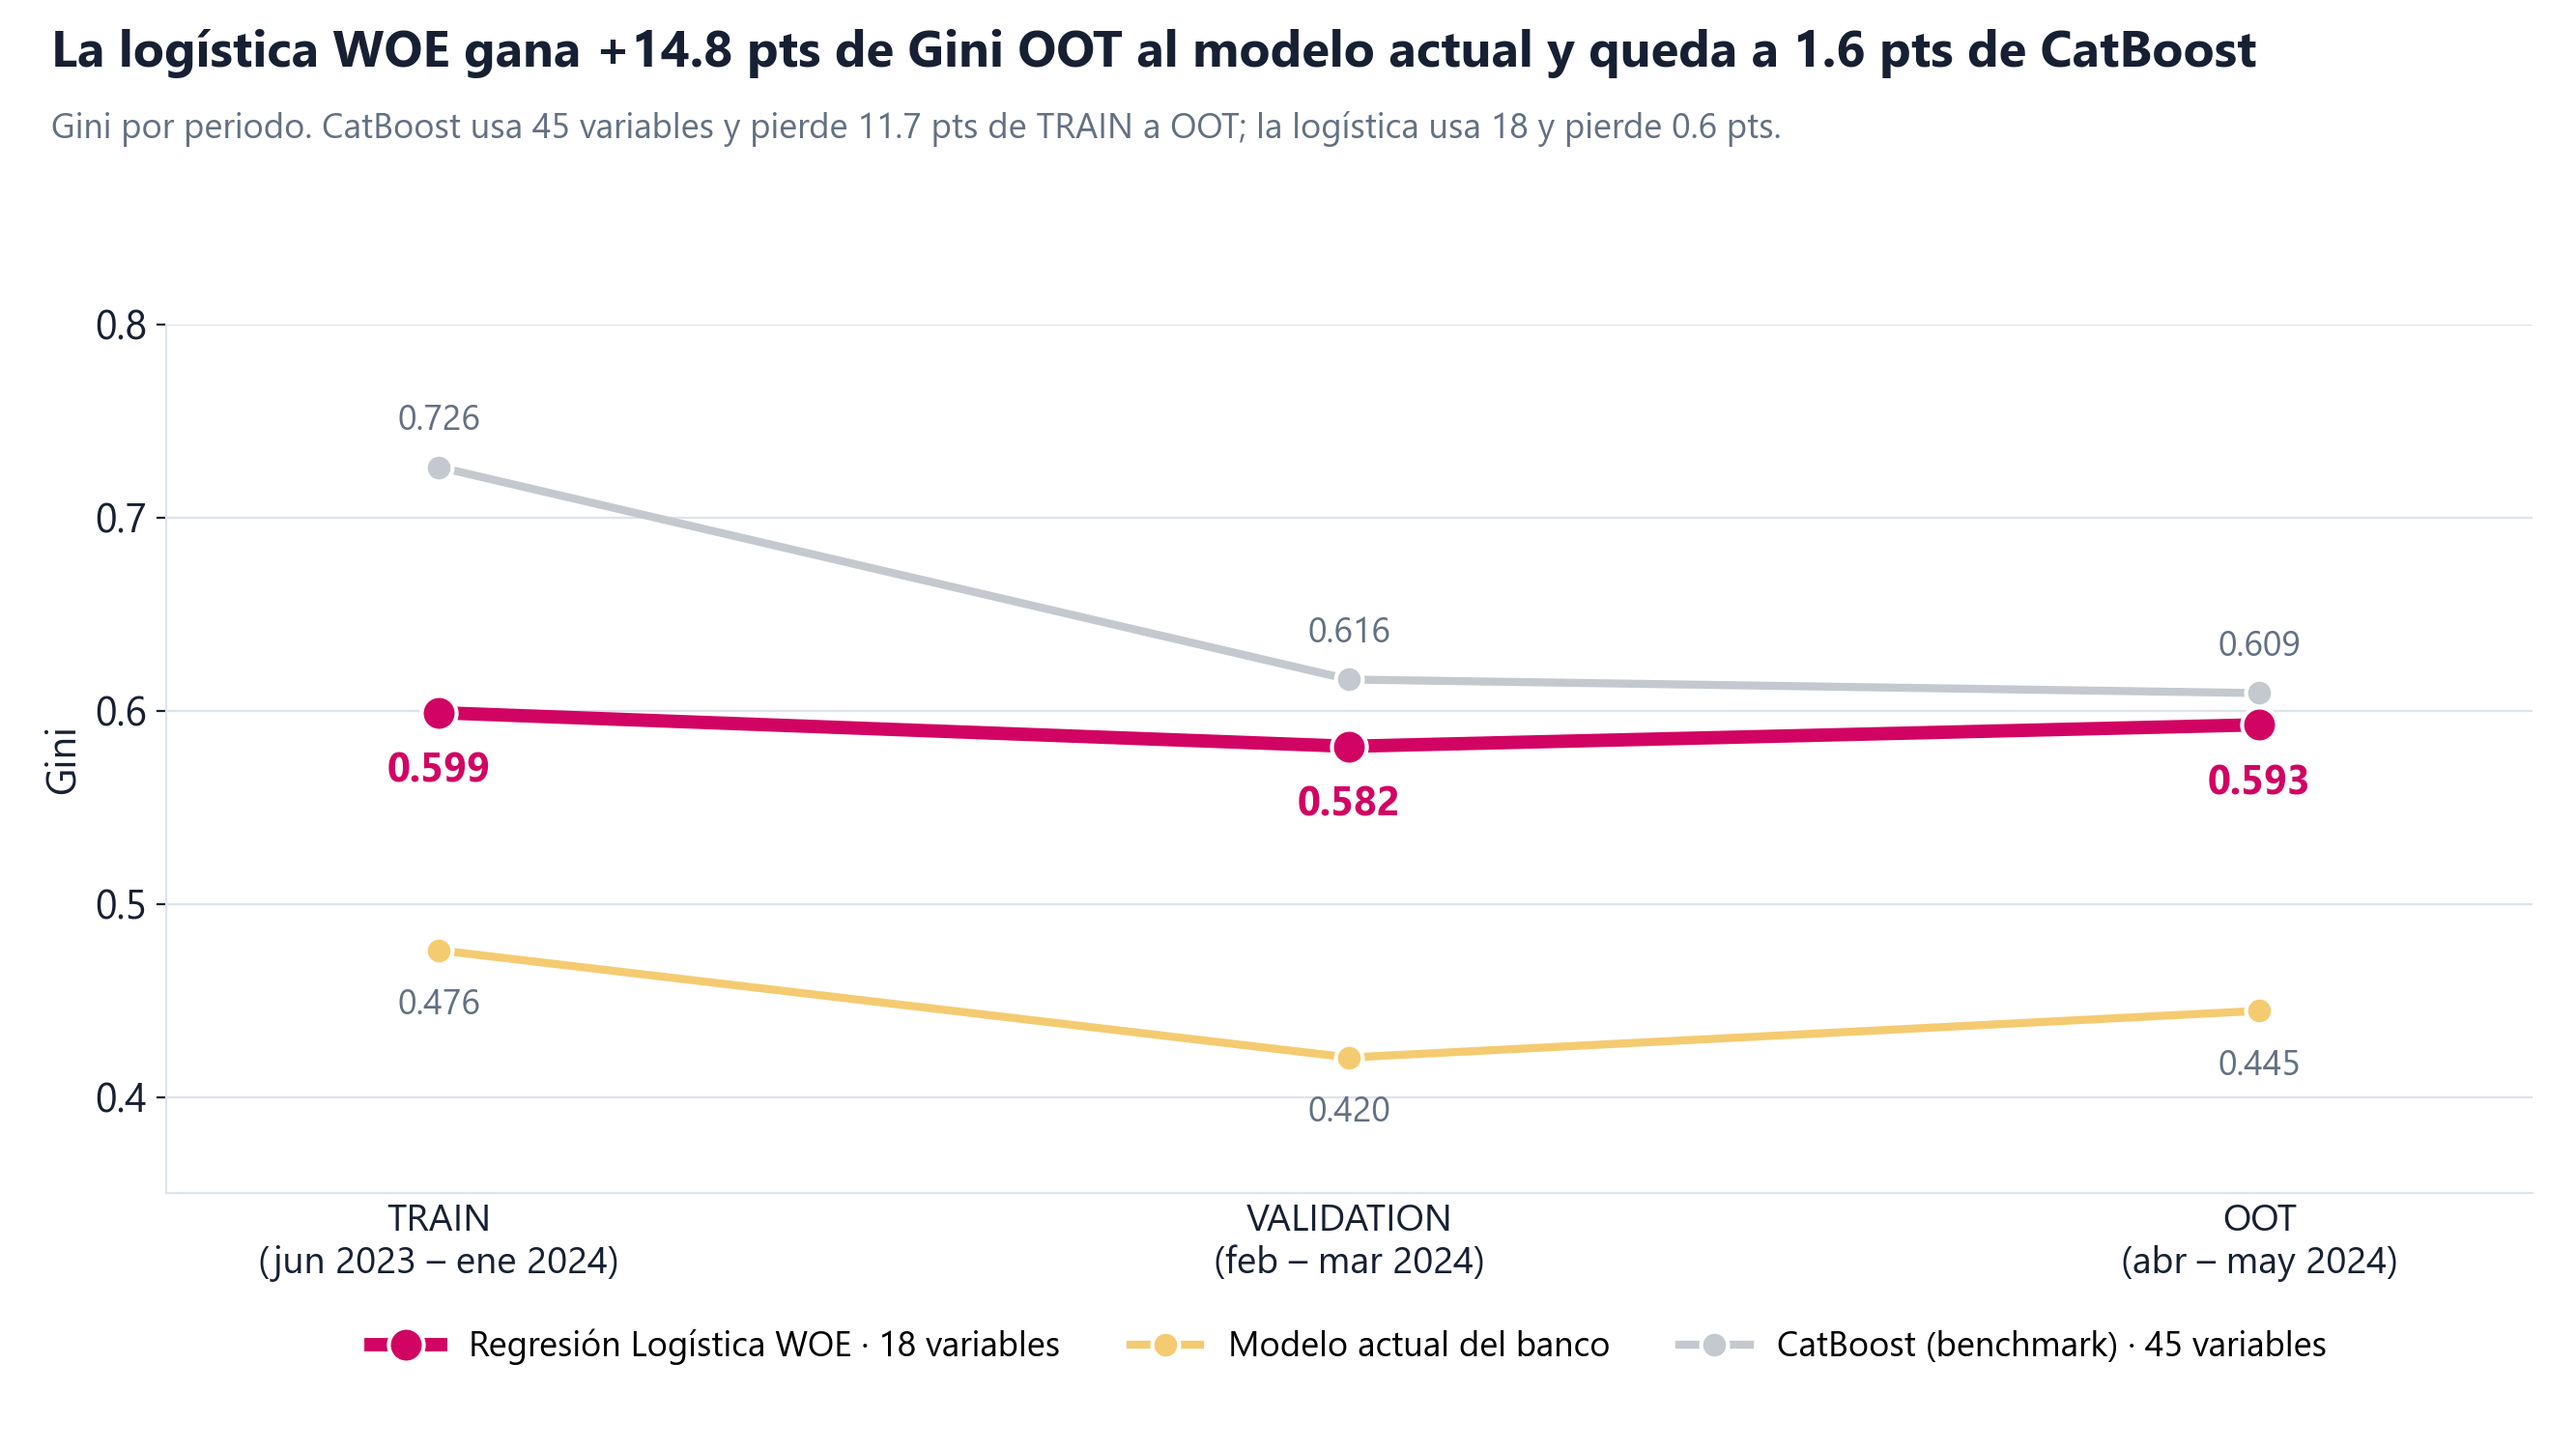

In [3]:
comp = r["comparacion"]
metricas = {c: "{:.3f}" for c in comp.columns if c.split("_")[0] in ("Gini", "AUC", "KS")}
display(comp.style.format({**metricas, "caida_gini_train_oot_pts": "{:.1f}"}).hide(axis="index"))
display(Image(str(ie.OUT_DIR / "comparacion_modelos.png"), width=1000))

### Calibración por bandas de PD (riesgo estimado vs. riesgo observado)

Réplica del backtesting de Manolo (notebook 01, celdas 130 y 133), calculada sobre las PD reales. Se verifica contra su tabla publicada de VALIDATION. Incluye el test bajo independencia y la sensibilidad Vasicek (rho de 0.5% a 3%). Se muestra también OOT, que Manolo no reportó.

,compatible_independencia,compatible_vasicek_todos_rho
muestra,,
VALIDATION,6,7
OOT,2,4


muestra,banda_pd,clientes,pd_promedio_pct,bad_rate_pct,gap_pp,p_value_independencia,vasicek_rho_0.5pct_compatible,vasicek_rho_1pct_compatible,vasicek_rho_2pct_compatible,vasicek_rho_3pct_compatible,compatible_independencia,compatible_vasicek_todos_rho
VALIDATION,0%-5%,2655,2.73,2.94,-0.21,0.5023,True,True,True,True,True,True
VALIDATION,5%-10%,2343,7.39,6.57,0.82,0.1280,True,True,True,True,True,True
VALIDATION,10%-15%,1718,12.38,11.47,0.91,0.2498,True,True,True,True,True,True
VALIDATION,15%-20%,1175,17.35,17.36,-0.01,0.9944,True,True,True,True,True,True
VALIDATION,20%-30%,1193,24.15,20.70,3.44,0.0053,True,True,True,True,False,True
VALIDATION,30%-40%,581,34.55,34.08,0.47,0.8120,True,True,True,True,True,True
VALIDATION,40%+,918,57.63,54.90,2.73,0.0817,True,True,True,True,True,True
OOT,0%-5%,2600,2.74,2.69,0.05,0.8846,True,True,True,True,True,True
OOT,5%-10%,2408,7.40,5.94,1.47,0.0059,True,True,True,True,False,True
OOT,10%-15%,1711,12.33,8.65,3.68,0.0000,False,False,True,True,False,False


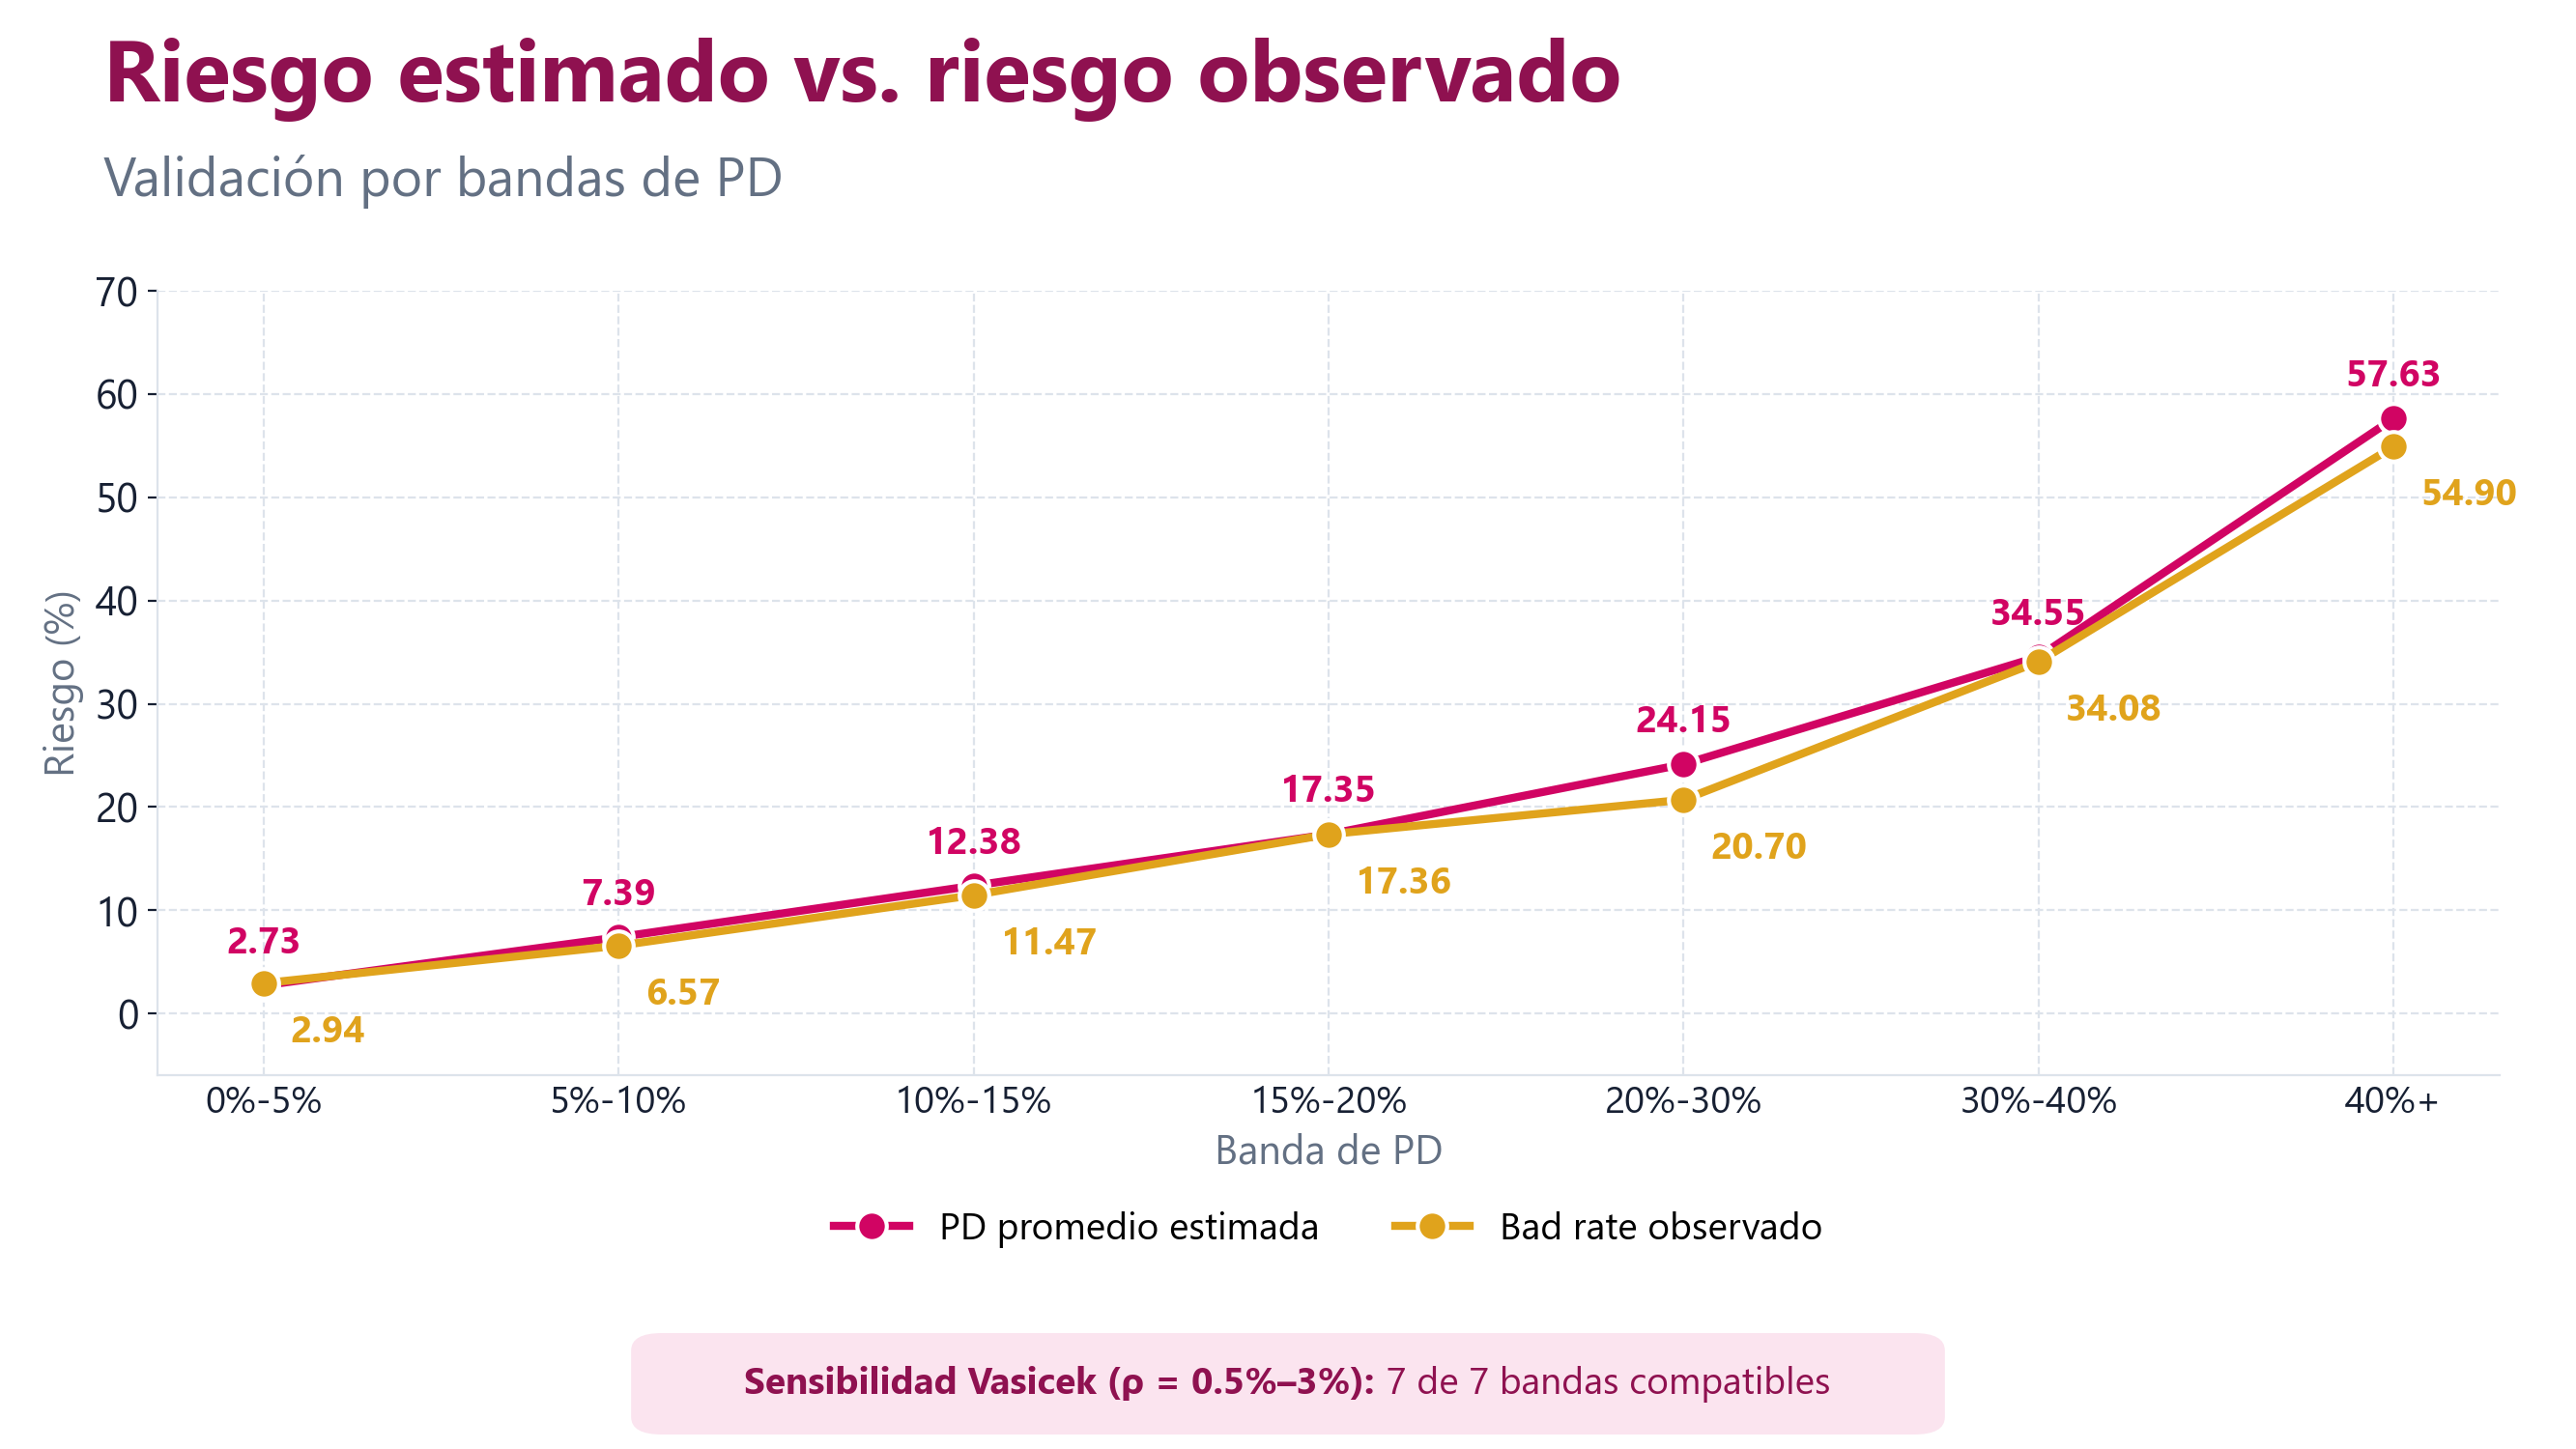

In [4]:
cal = r["calibracion"]
display(cal.groupby("muestra", sort=False)[["compatible_independencia", "compatible_vasicek_todos_rho"]].sum())
display(cal.style.format({c: "{:.2f}" for c in ["pd_promedio_pct", "bad_rate_pct", "gap_pp"]} | {"p_value_independencia": "{:.4f}"}).hide(axis="index"))
display(Image(str(ie.OUT_DIR / "calibracion_bandas.png"), width=1000))

### Patrones de riesgo de las variables finales (bad rate por bin WOE)

Bad rate por bin de las 18 variables, con los bins del artefacto de Manolo, en TRAIN (desarrollo) y OOT. Se grafican tres: la creciente de mayor IV en cada familia de riesgo (`ie.VARIABLES_LAMINA`).

**Hallazgo:** en `MEDIDA3_APALANCAMIENTO_INTERNO_U1M` el centinela 333333344 no se trata como bin especial al aplicar el modelo (ver `clientes` vs `clientes_artefacto`).

variable,iv,direccion_OOT,direccion_TRAIN
MEDIDA1_MORA_INTERNA_U6M,0.470,creciente,creciente
MEDIDA1_MORA_INTERNA_U1M,0.301,creciente,creciente
MEDIDA1_MORA_SSFF_U36M,0.277,decreciente,decreciente
MEDIDA2_MORA_INTERNA_U6M,0.174,decreciente,decreciente
MEDIDA1_DESAPALANCAMIENTO_SSFF_U12M,0.129,decreciente,decreciente
MEDIDA3_APALANCAMIENTO_INTERNO_U1M,0.125,no monótona,no monótona
MEDIDA1_DESAPALANCAMIENTO_INTERNO_U12M,0.123,decreciente,decreciente
MEDIDA2_CALIFICACION_SSFF_U60M,0.123,decreciente,decreciente
MEDIDA1_APALANCAMIENTO_SSFF_U36M,0.120,creciente,creciente
MEDIDA1_CALIFICACION_SSFF_U60M,0.115,creciente,creciente


,muestra,variable,iv,orden,bin,etiqueta,especial,clientes,bad_rate,clientes_artefacto,bad_rate_artefacto
149,TRAIN,MEDIDA3_APALANCAMIENTO_INTERNO_U1M,0.125,4,"[1.2800000000000007,inf)",≥ 1.28,False,5202,0.172241,2238.0,0.201966
150,TRAIN,MEDIDA3_APALANCAMIENTO_INTERNO_U1M,0.125,100,3.3333334e+08,3.3333334e+08 (especial),True,0,NaN,2964.0,0.149798


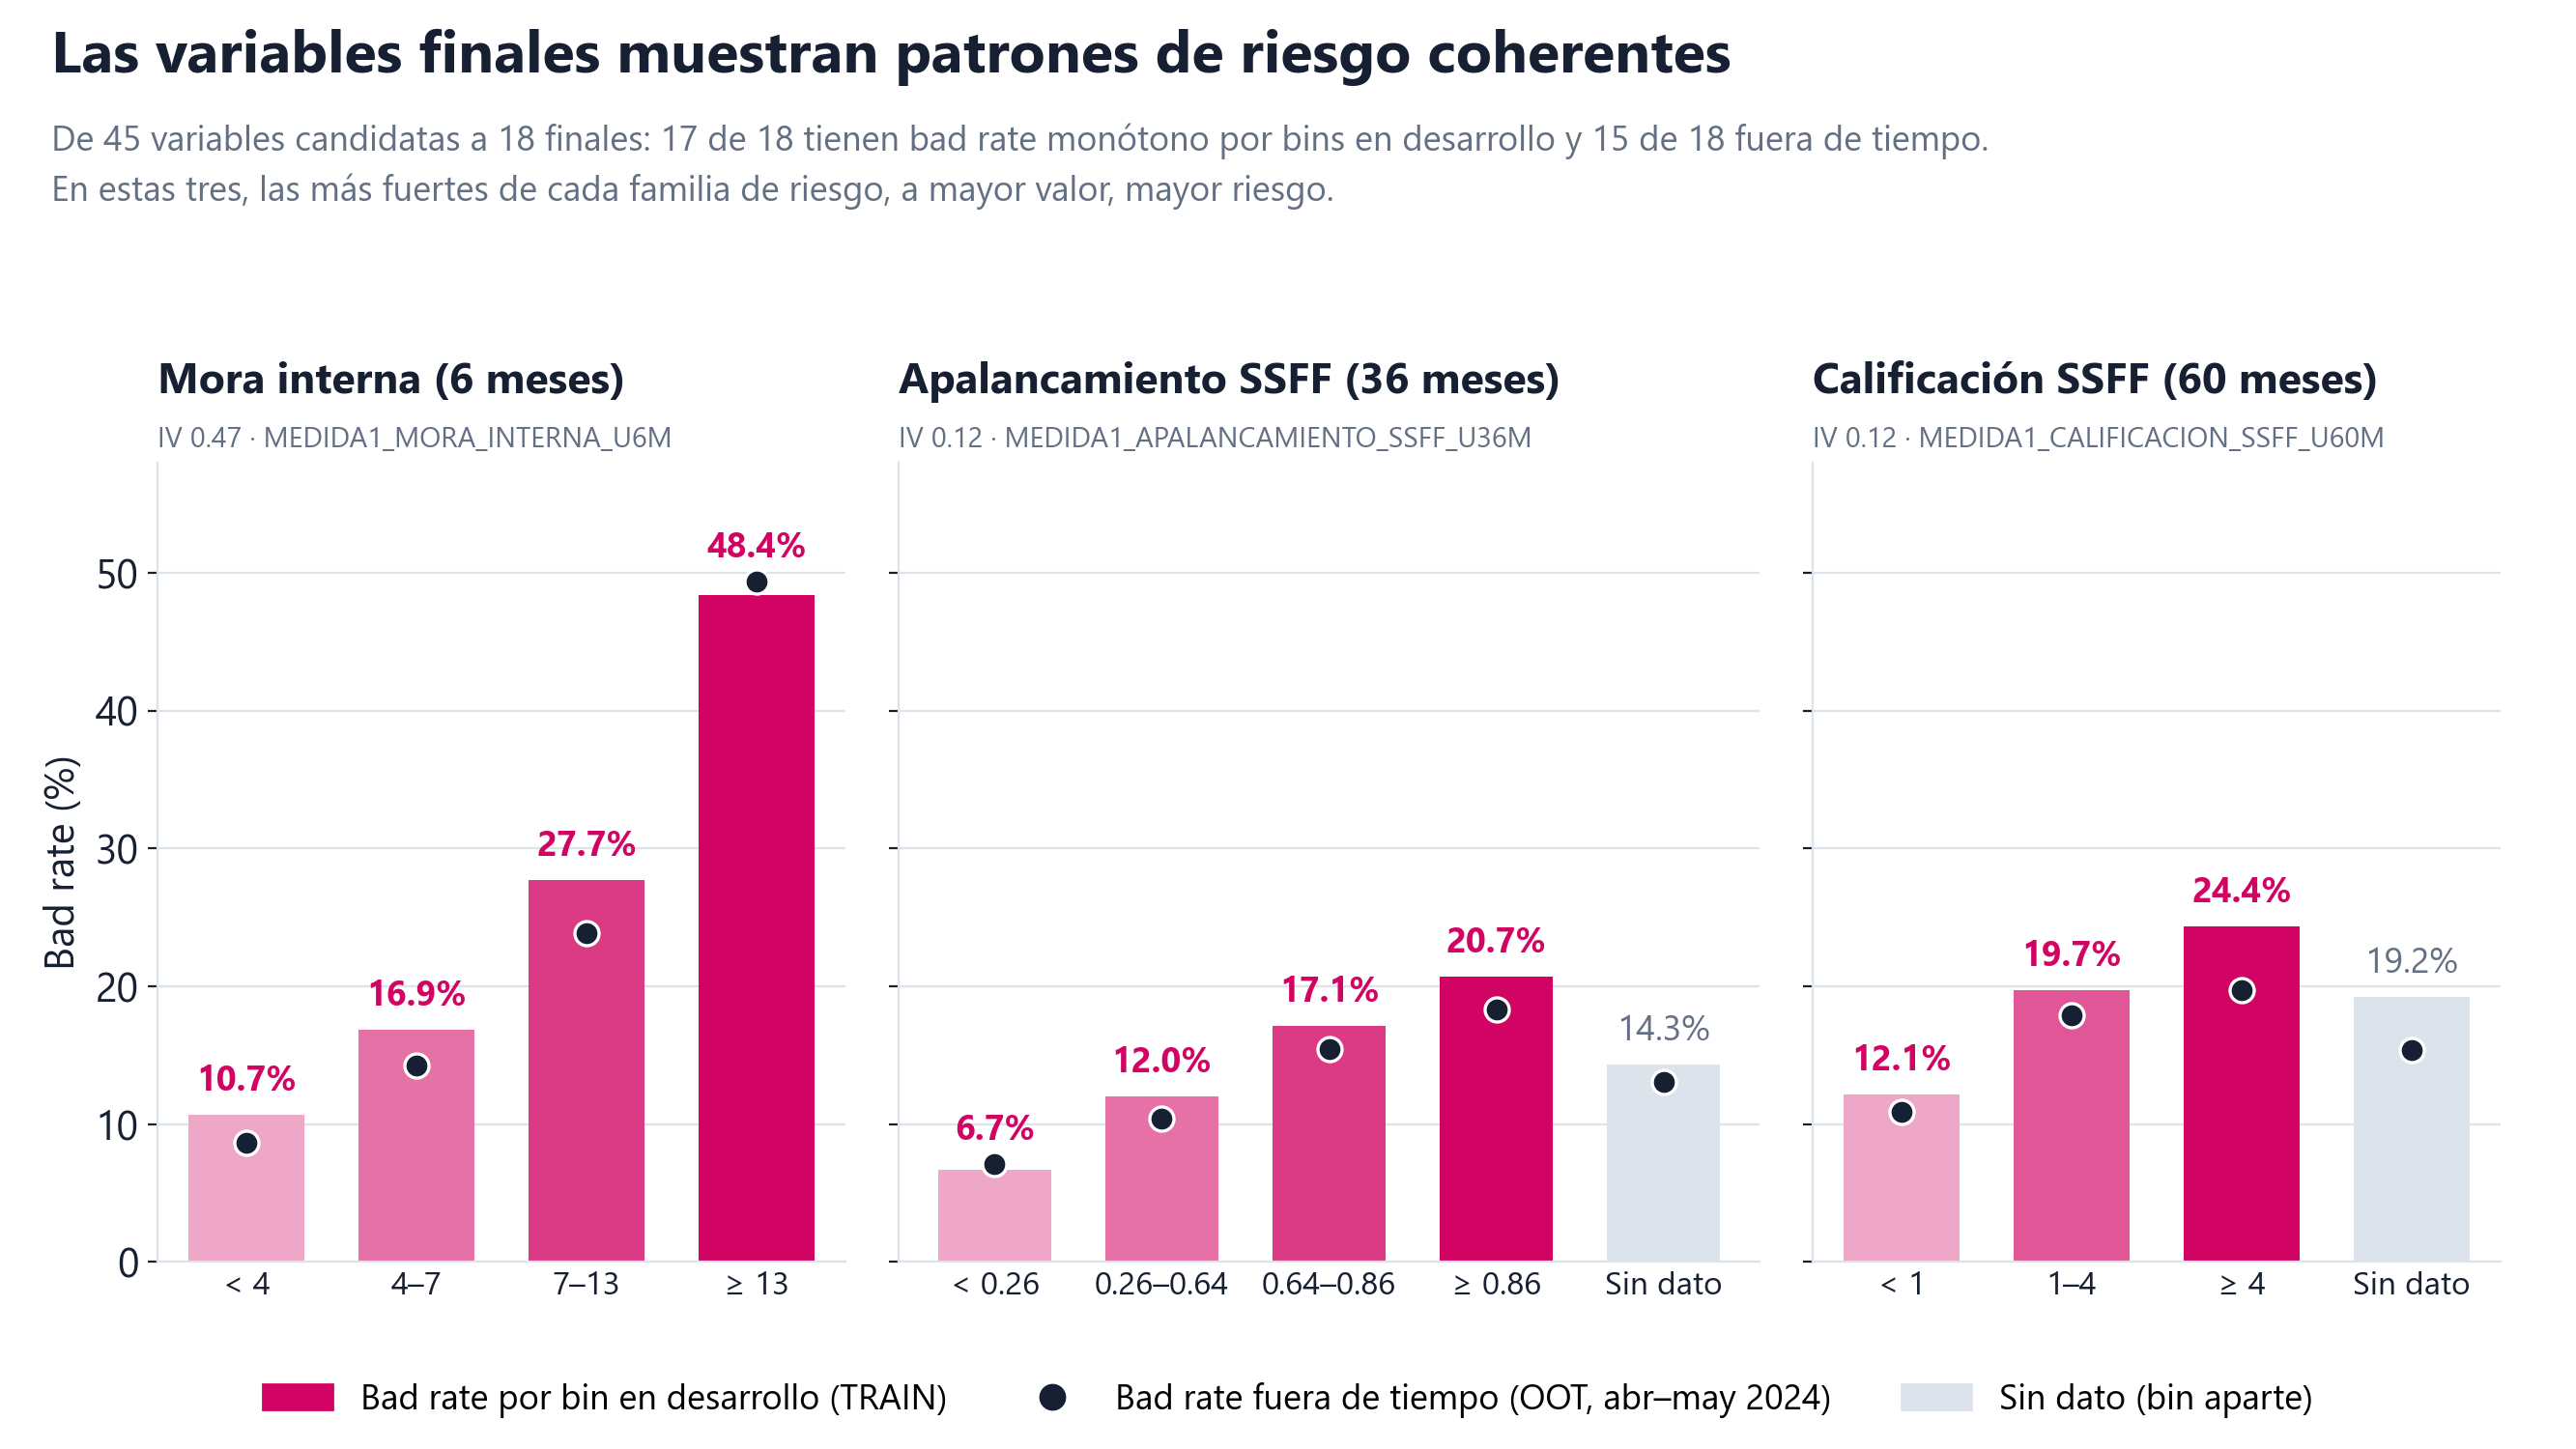

In [5]:
display(r["monotonia"].style.format({"iv": "{:.3f}"}).hide(axis="index"))
pat = r["patrones"]
display(pat[(pat["muestra"] == "TRAIN") & (pat["clientes"] != pat["clientes_artefacto"])])
display(Image(str(ie.OUT_DIR / "patrones_variables.png"), width=1000))

## 2. Supuestos y economía por cliente

La base está anonimizada: no trae monto, tasa, plazo, saldo ni recuperaciones. Todos los parámetros económicos son supuestos y están centralizados en `ie.SUPUESTOS`.

In [6]:
display(r["supuestos"].style.hide(axis="index"))
print(f"Ganancia por cliente bueno aprobado: S/ {r['ganancia_por_bueno']:,.0f}")
print(f"Pérdida por cliente malo aprobado:   S/ {r['perdida_por_malo']:,.0f}")
print(f"PD de equilibrio G/(G+L):            {r['pd_equilibrio']:.1%}  (política de Manolo: PD < 20%)")
print(f"Óptimo económico en VALIDATION:      {r['optimo_validation_pct']}% de aprobación")

parametro,valor,fuente
monto,5000,Supuesto: la base no trae monto desembolsado (S/ por crédito)
tea,0.450000,Supuesto: TEA de referencia para crédito de renovación; la base no trae tasa
plazo_meses,12,Supuesto: la base no trae plazo
costo_fondeo,0.070000,Supuesto: costo de fondeo anual
costo_operativo,0.120000,Supuesto: costo operativo anual sobre saldo
saldo_medio,0.550000,Supuesto: saldo medio de un crédito amortizable (% del monto)
lgd,0.700000,Supuesto: pérdida dado el incumplimiento; la base no trae recuperaciones
ead,0.800000,Supuesto: exposición al incumplimiento (% del monto)
costo_cobranza,150,Supuesto: costo de cobranza por crédito malo (S/)
definicion_malo,TARGET = 1,Supuesto: todo TARGET = 1 es un default con pérdida (definición no publicada)


Ganancia por cliente bueno aprobado: S/ 715
Pérdida por cliente malo aprobado:   S/ 2,950
PD de equilibrio G/(G+L):            19.5%  (política de Manolo: PD < 20%)
Óptimo económico en VALIDATION:      73% de aprobación


## 3. Escenarios

Identidades verificadas en código: ganancia de buenos − pérdida de malos = utilidad neta, y utilidad actual + pérdida evitada − ganancia sacrificada = utilidad del escenario.

In [7]:
cols = ["escenario", "umbral_pd", "aprobacion_pct", "tasa_malos_aprobados_pct", "ganancia_buenos", "perdida_malos",
        "utilidad_neta", "perdida_evitada", "ganancia_sacrificada", "ahorro_vs_actual", "ahorro_vs_banco"]
money = cols[4:]
for m in ["OOT", "VALIDATION"]:
    print(f"Escenarios — {m}")
    t = r["escenarios"].loc[r["escenarios"]["muestra"] == m, cols]
    display(formato(t, soles=money, pct=["aprobacion_pct", "tasa_malos_aprobados_pct"]).format({"umbral_pd": "{:.2%}"}, na_rep="—"))

Escenarios — OOT


escenario,umbral_pd,aprobacion_pct,tasa_malos_aprobados_pct,ganancia_buenos,perdida_malos,utilidad_neta,perdida_evitada,ganancia_sacrificada,ahorro_vs_actual,ahorro_vs_banco
A. Situación actual (aprobar a todos),—,100.000000,14.130534,6726005.000000,4566600.000000,2159405.000000,0.000000,0.000000,0.000000,-868870.000000
B. Modelo del banco (igual volumen),—,73.473300,9.243384,5223075.000000,2194800.000000,3028275.000000,2371800.000000,1502930.000000,868870.000000,0.000000
C. Modelo propuesto PD < 20%,20.00%,73.473300,6.957386,5354635.000000,1652000.000000,3702635.000000,2914600.000000,1371370.000000,1543230.000000,674360.000000
D. Óptimo económico (elegido en VALIDATION: 73% aprob.),19.20%,71.811958,6.711580,5247385.000000,1557600.000000,3689785.000000,3009000.000000,1478620.000000,1530380.000000,661510.000000
E. 90% de aprobación (umbral de VALIDATION),36.98%,89.091739,9.713115,6300580.000000,2796600.000000,3503980.000000,1770000.000000,425425.000000,1344575.000000,475705.000000
F. 80% de aprobación (umbral de VALIDATION),23.46%,78.813327,7.702108,5697835.000000,1961750.000000,3736085.000000,2604850.000000,1028170.000000,1576680.000000,707810.000000


Escenarios — VALIDATION


escenario,umbral_pd,aprobacion_pct,tasa_malos_aprobados_pct,ganancia_buenos,perdida_malos,utilidad_neta,perdida_evitada,ganancia_sacrificada,ahorro_vs_actual,ahorro_vs_banco
A. Situación actual (aprobar a todos),—,100.000000,14.948502,6435715.000000,4666900.000000,1768815.000000,0.000000,0.000000,0.000000,-882610.000000
B. Modelo del banco (igual volumen),—,74.562978,10.340895,5058625.000000,2407200.000000,2651425.000000,2259700.000000,1377090.000000,882610.000000,0.000000
C. Modelo propuesto PD < 20%,20.00%,74.562978,8.021797,5189470.000000,1867350.000000,3322120.000000,2799550.000000,1246245.000000,1553305.000000,670695.000000
D. Óptimo económico (elegido en VALIDATION: 73% aprob.),19.20%,72.994425,7.663430,5100095.000000,1746400.000000,3353695.000000,2920500.000000,1335620.000000,1584880.000000,702270.000000
E. 90% de aprobación (umbral de VALIDATION),36.98%,89.993386,10.825283,6072495.000000,3041450.000000,3031045.000000,1625450.000000,363220.000000,1262230.000000,379620.000000
F. 80% de aprobación (umbral de VALIDATION),23.46%,79.996220,8.882589,5515510.000000,2218400.000000,3297110.000000,2448500.000000,920205.000000,1528295.000000,645685.000000


## 4. Curva de utilidad (OOT)

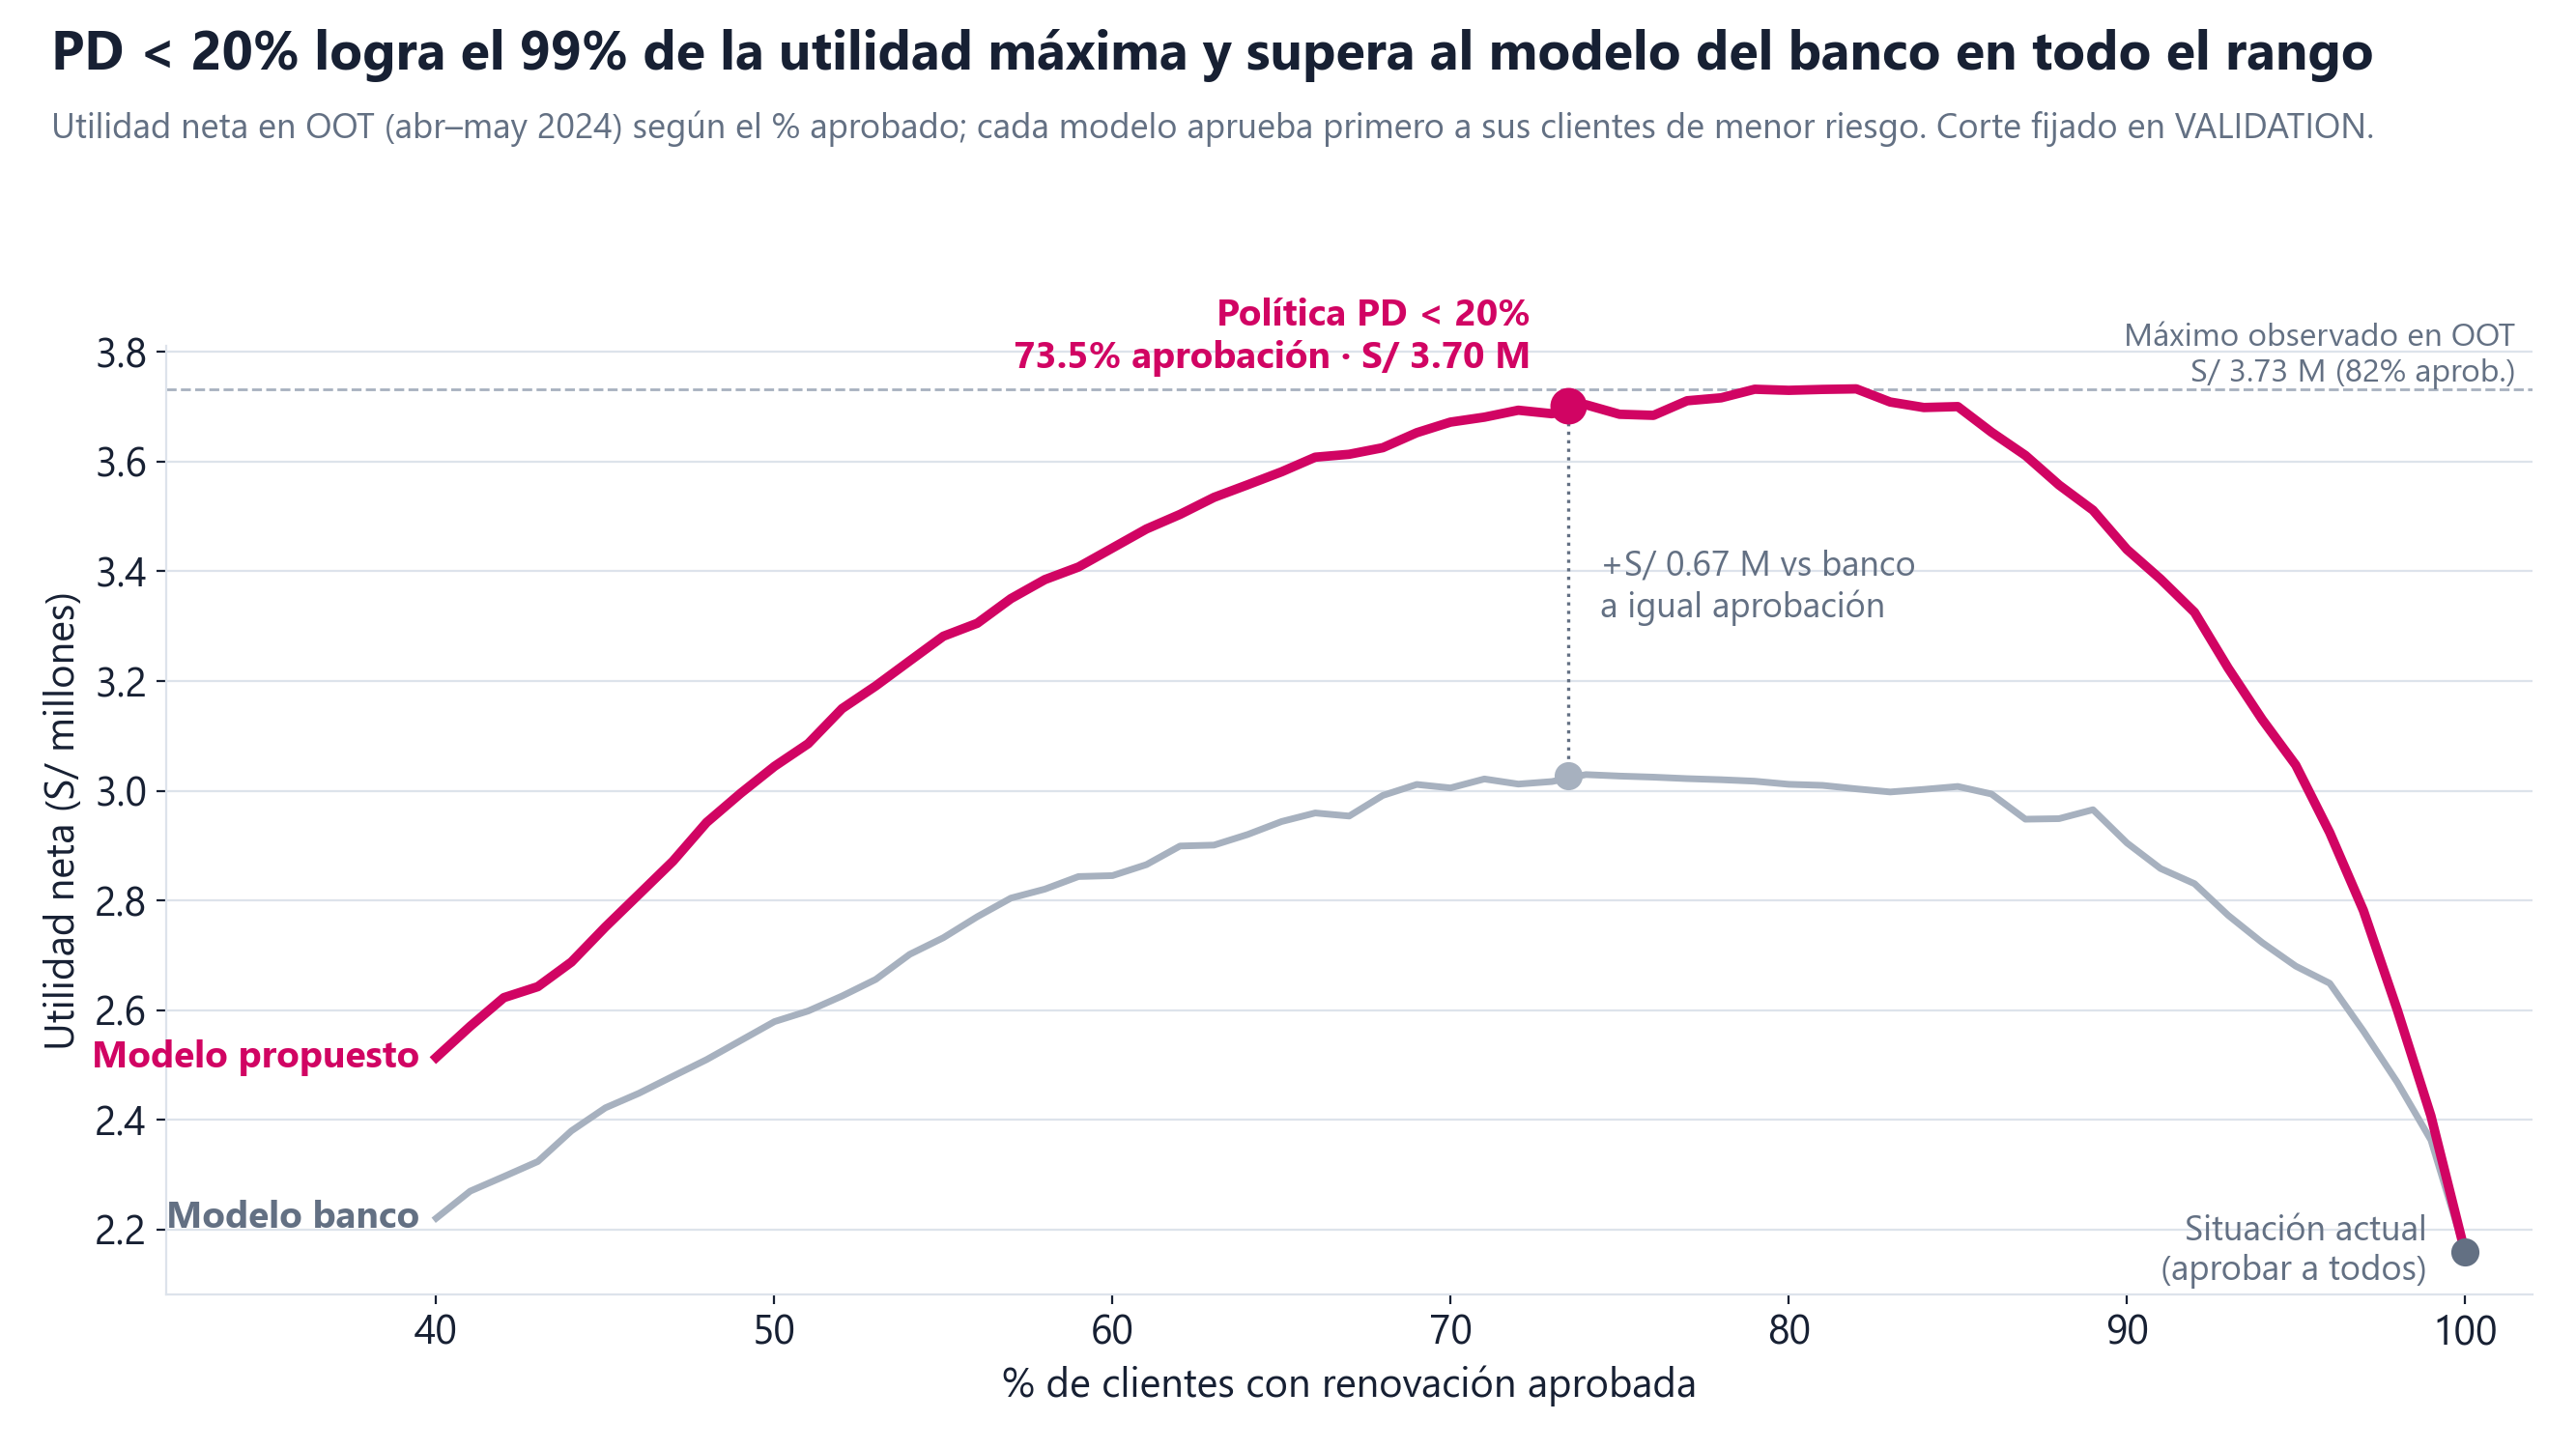

In [8]:
display(Image(str(ie.OUT_DIR / "curva_utilidad.png"), width=1000))

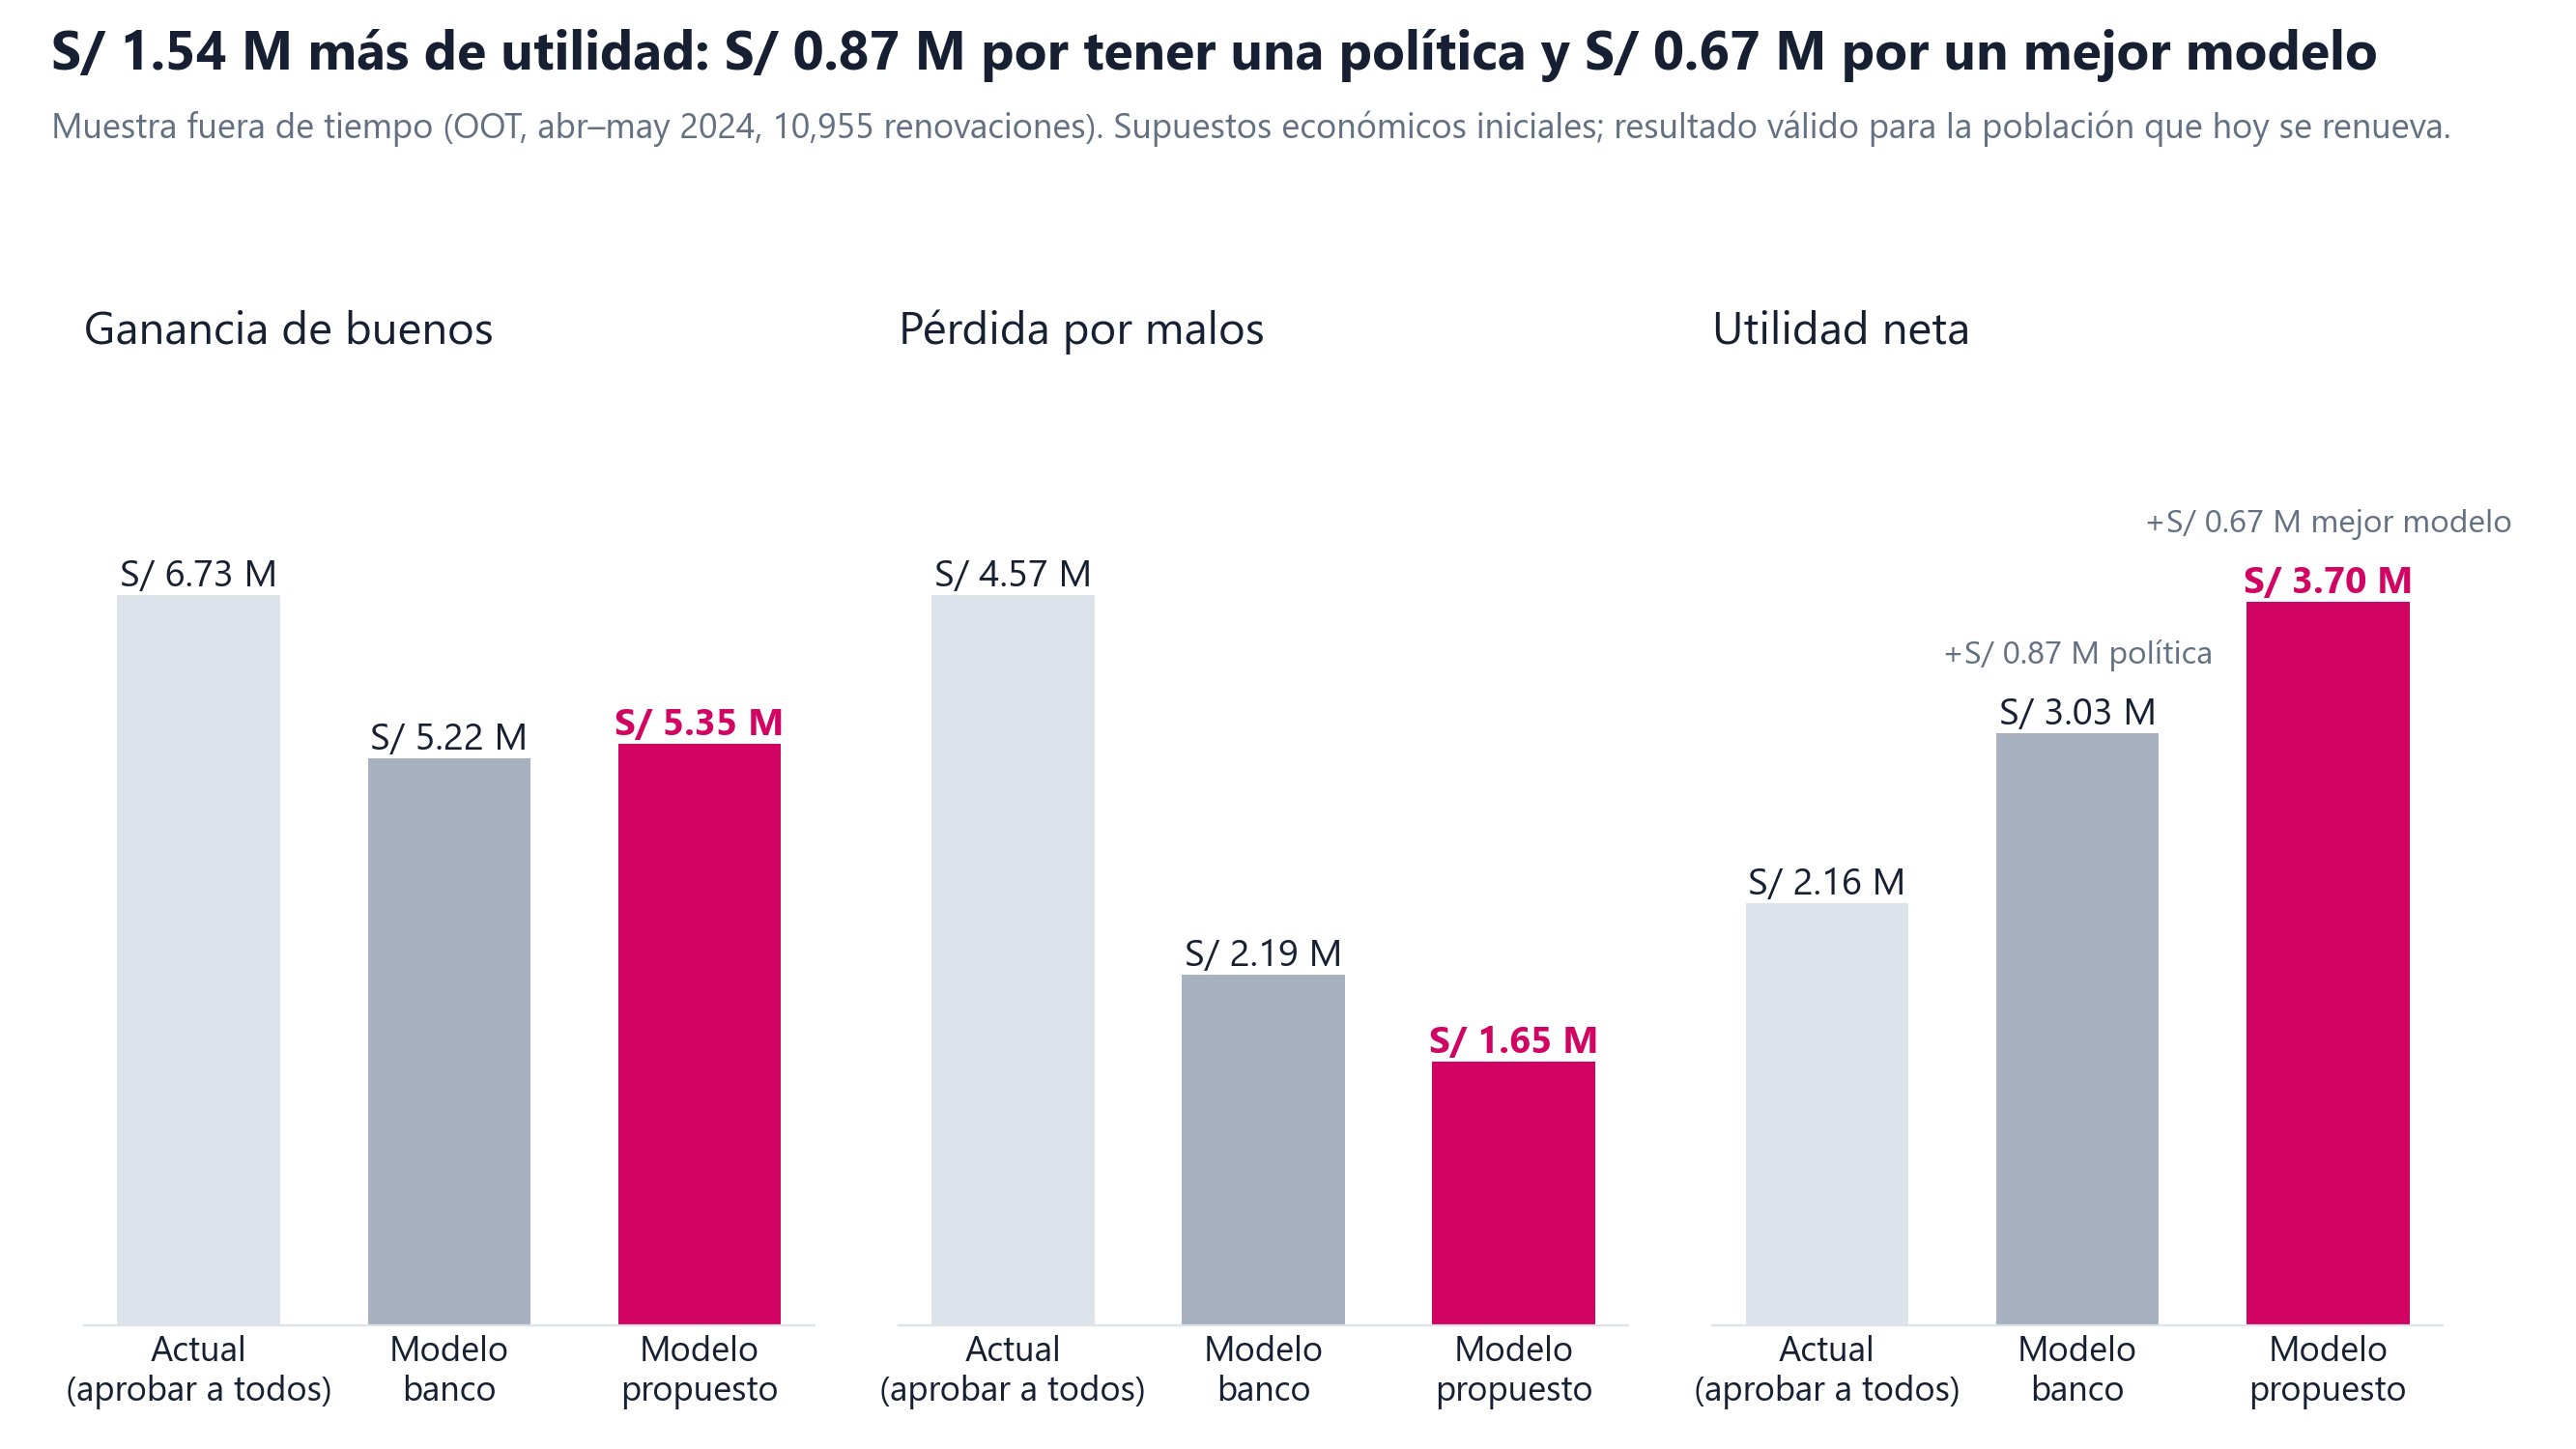

In [9]:
display(Image(str(ie.OUT_DIR / "barras_impacto.png"), width=1000))

## 5. Estabilidad en el tiempo

Ahorro por mes con el umbral fijo PD < 20%, descompuesto en valor de la política y valor del mejor modelo.

In [10]:
e = r["estabilidad"]
formato(e, soles=["ahorro_total", "ahorro_politica", "ahorro_modelo", "ahorro_total_por_1000"],
        pct=["bad_rate_pct", "aprobacion_pct", "tasa_malos_aprobados_pct", "tasa_malos_banco_pct"])

muestra,codmes,n,bad_rate_pct,aprobacion_pct,tasa_malos_aprobados_pct,tasa_malos_banco_pct,ahorro_total,ahorro_politica,ahorro_modelo,ahorro_total_por_1000
VALIDATION,202402,5263,15.24%,72.92%,8.00%,10.32%,"S/ 795,300","S/ 469,115","S/ 326,185","S/ 151,112"
VALIDATION,202403,5320,14.66%,76.18%,8.04%,10.39%,"S/ 758,005","S/ 409,830","S/ 348,175","S/ 142,482"
OOT,202404,5425,14.21%,74.47%,7.25%,9.65%,"S/ 761,595","S/ 406,090","S/ 355,505","S/ 140,386"
OOT,202405,5530,14.05%,72.50%,6.66%,8.95%,"S/ 781,635","S/ 444,455","S/ 337,180","S/ 141,344"


## 6. Robustez

**Bootstrap** (1000 réplicas, OOT, umbrales congelados). Remuestrea clientes de forma independiente, así que no captura la correlación entre defaults: el intervalo real es algo más ancho.

In [11]:
formato(r["bootstrap"], soles=["estimado", "media_bootstrap", "ic95_inf", "ic95_sup"])

metrica,estimado,media_bootstrap,ic95_inf,ic95_sup,prob_ahorro_positivo,replicas
ahorro_total,"S/ 1,543,230","S/ 1,545,929","S/ 1,361,848","S/ 1,729,972",1.000000,1000
ahorro_politica,"S/ 868,870","S/ 870,605","S/ 692,121","S/ 1,048,194",1.000000,1000
ahorro_modelo,"S/ 674,360","S/ 675,324","S/ 530,687","S/ 822,622",1.000000,1000


**Sensibilidad** (OOT, umbral fijo PD < 20%): LGD y margen ±20%.

In [12]:
s = r["sensibilidad"]
formato(s, soles=["ganancia_por_bueno", "perdida_por_malo", "utilidad_actual", "utilidad_banco", "utilidad_propuesto",
                  "ahorro_total", "ahorro_politica", "ahorro_modelo"],
        pct=["pd_equilibrio_pct", "ahorro_total_pct"]).format({"lgd": "{:.0%}", "factor_lgd": "{:.1f}", "factor_margen": "{:.1f}"})

factor_lgd,lgd,factor_margen,ganancia_por_bueno,perdida_por_malo,pd_equilibrio_pct,utilidad_actual,utilidad_banco,utilidad_propuesto,ahorro_total,ahorro_politica,ahorro_modelo,ahorro_total_pct
0.8,56%,0.8,572.000000,2390.000000,19.311276,1681084.000000,2400300.000000,2945308.000000,1264224.000000,719216.000000,545008.000000,75.202905
0.8,56%,1.0,715.000000,2390.000000,23.027375,3026285.000000,3444915.000000,4016235.000000,989950.000000,418630.000000,571320.000000,32.711724
0.8,56%,1.2,858.000000,2390.000000,26.416256,4371486.000000,4489530.000000,5087162.000000,715676.000000,118044.000000,597632.000000,16.371458
1.0,70%,0.8,572.000000,2950.000000,16.240772,814204.000000,1983660.000000,2631708.000000,1817504.000000,1169456.000000,648048.000000,223.224646
1.0,70%,1.0,715.000000,2950.000000,19.508868,2159405.000000,3028275.000000,3702635.000000,1543230.000000,868870.000000,674360.000000,71.465519
1.0,70%,1.2,858.000000,2950.000000,22.531513,3504606.000000,4072890.000000,4773562.000000,1268956.000000,568284.000000,700672.000000,36.208236
1.2,84%,0.8,572.000000,3510.000000,14.012739,-52676.000000,1567020.000000,2318108.000000,2370784.000000,1619696.000000,751088.000000,4500.691017
1.2,84%,1.0,715.000000,3510.000000,16.923077,1292525.000000,2611635.000000,3389035.000000,2096510.000000,1319110.000000,777400.000000,162.202665
1.2,84%,1.2,858.000000,3510.000000,19.642857,2637726.000000,3656250.000000,4459962.000000,1822236.000000,1018524.000000,803712.000000,69.083597
